In [1]:
from deep_kolmogorov import modeling, pdes, trainer
import torch

import importlib
importlib.reload(modeling)

<module 'deep_kolmogorov.modeling' from '/home/ycui/Documents/my_deepkol/deep_kolmogorov/modeling.py'>

In [2]:
def get_option_price_curve_d_10(model, K, num_path, config):
    device = torch.device("cuda")
    with torch.no_grad(): 
        data = {
            key: torch.tensor((K+1)*num_path * [value], dtype=torch.float32, device=device) for key, value in config.items()
        }
        data.update(
            {
                "t": torch.linspace(model.pde.hypercubes["t"].interval[0], model.pde.hypercubes["t"].interval[1], K + 1, dtype=torch.float32, device=device).repeat(num_path).reshape(-1,1)
            }
        )
        batch = {
            key:torch.tensor(num_path * [value], dtype=torch.float32, device=device) for key, value in config.items()
        }
        x = torch.full((num_path,len(config["s"]),K+1), 1, dtype=torch.float32, device=device)
        for i in range(K+1):
            x[:, :, i] = batch["s"].clone()
            n = len(config["s"])
            if type(model.pde).__name__ == "BSbasket":
                RHO = batch["rho"].view(num_path, 1, 1).expand(num_path, n, n).clone()
                RHO.as_strided((num_path, n), (n ** 2, n + 1)).fill_(1)
                sqrt_cov = torch.linalg.cholesky(RHO)

                dw = (1/K)**0.5 * torch.matmul(sqrt_cov, 
                                                        torch.randn(batch["s"].shape, dtype=batch["s"].dtype, device=batch["s"].device).unsqueeze(2)
                ).squeeze(2)
                batch["s"] = batch["s"] * torch.exp(
                    batch["r"] * 1/K - 0.5 * 1/K * batch["sigma"] ** 2 + batch["sigma"] * dw
                )
            elif type(model.pde).__name__ == "MJDbasket":
                RHO = batch["rho_b"].view(num_path, 1, 1).expand(num_path, n, n).clone()
                RHO.as_strided((num_path, n), (n ** 2, n + 1)).fill_(1)
                sqrt_cov = torch.linalg.cholesky(RHO)

                dw = (1/K)**0.5 * torch.matmul(sqrt_cov, 
                                                        torch.randn(batch["s"].shape, dtype=batch["s"].dtype, device=batch["s"].device).unsqueeze(2)
                ).squeeze(2)
                muj = torch.exp(batch["m"] + 0.5 * batch["delta"] ** 2) - 1
                num_j = torch.poisson(
                    1/K * batch["lambda"]
                )
                RHO = batch["rho_j"].view(num_path, 1, 1).expand(num_path, n, n).clone()
                RHO.as_strided((num_path, n), (n ** 2, n + 1)).fill_(1)
                sqrt_cov = torch.linalg.cholesky(RHO)
                jumps = num_j * batch["m"] + torch.sqrt(num_j) * batch["delta"] * torch.matmul(sqrt_cov, 
                                                        torch.randn(batch["s"].shape, dtype=batch["s"].dtype, device=batch["s"].device).unsqueeze(2)
                ).squeeze(2)

                batch["s"] = batch["s"] * torch.exp(
                    batch["r"] * 1/K - batch["lambda"] * muj * 1/K  - 0.5 * 1/K * batch["sigma"] ** 2 + batch["sigma"] * dw + jumps
                )
            elif type(model.pde).__name__ == "BSbasketTI":
                rmt = model.pde.get_rmt(i/K, (i+1)/K, batch["r0"], batch["r1"], batch["r2"])
                s2mt = model.pde.get_s2mt(i/K, (i+1)/K, 1, batch["sigma_bar"], batch["beta"])
                batch["s"] = batch["s"] * torch.exp(
                    rmt - 0.5 * s2mt + torch.sqrt(s2mt)/(1/K)** 0.5 * dw
                )


        data["x"] = x.transpose(1,2).reshape(-1,len(config["s"]))
        if model.pde.get_K is not None:
            data["K"] = model.pde.get_K(data)
        if model.pde.get_r is not None:
            data["r"] = model.pde.get_r(data)
        if model.pde.get_sigma is not None:
            data["sigma"] = model.pde.get_sigma(data)
        tensor = model.pde.normalize_and_flatten(data)
        y_pred = model.net.forward(tensor)
        y_true = model.pde.solution(data)
    return {
        "t": data["t"].reshape(num_path, K+1),
        "y_pred": y_pred.reshape(num_path, K+1),
        "y_true": y_true.reshape(num_path, K+1),
        "data": data
        }


In [3]:
import matplotlib.pyplot as plt

def plot_mc_curves(t_test, y_pred, y_true=None):
    if t_test.device != "cpu":
        t_test= t_test.cpu()
    if y_pred.device != "cpu":
        y_pred= y_pred.cpu()
    if y_true.device != "cpu":
        y_true= y_true.cpu()
    samples = 16
    plt.figure(figsize=(13, 8))
    plt.plot(t_test[0:1,:].T, y_pred[0:1,:].T,'darkviolet',label='Learned solution')
    plt.plot(t_test[0:1,:].T, y_true[0:1,:].T,'--',color='lightseagreen',label='Exact solution')
    # plt.plot(t_test[0:1,-1], y_true[0:1,-1],'ko')

    plt.plot(t_test[1:samples,:].T, y_pred[1:samples,:].T,'darkviolet')
    plt.plot(t_test[1:samples,:].T, y_true[1:samples,:].T,'--',color='lightseagreen')
    # plt.plot(t_test[1:samples,-1], y_true[1:samples,-1],'ko')

    # plt.plot([0],y_true[0,0],'ks') # ,label='$Y_0 = u(0,X_0)$')

    plt.xlabel('time', fontdict={"size": 18})
    plt.ylabel('price', fontdict={"size": 18})
    #plt.title(fr'm={u_hat[-1]: 2f}, r={u_hat[0]: 2f}, $\theta$={u_hat[1]: 2f},$\kappa$={u_hat[2]: 2f}， $\sigma$={u_hat[3]: 2f}, $\rho$={u_hat[4]: 2f}')# , $\rho$={u_hat[2]: 2f}')
    plt.legend(prop={"size": 15})
    plt.show()

# res = get_option_price_curve(model, 100, 2, {"s":9.5, "r":0.03, "sigma": 0.3, "kappa":1.05})
# plot_mc_curves(res["t"], res["y_pred"], res["y_true"])


In [22]:
config = {
  "bs": 120000,
  "checkpoint": True,
  "factor": 6,
  "gpus": 1,
  "levels": 4,
  "lr": 0.01,
  "lr_decay": 0.25,
  "lr_decay_patience": 2,
  "min_lr": 1e-08,
  "mode": "avg_bs_basket_PI",
  "n_iterations": 30,
  "n_test_batches": 1,
  "n_train_batches": 1,
  "net": "DeepONetwithPI",
  "norm_layer": "layernorm",
  "num_assets": 10,
  "num_depth": 7,
  "num_width": 75,
  "opt": "adamw",
  "pde": "BSbasket",
  "pi_layer": [
    100,
    100
  ],
  "seed": 0,
  "size_t_x_u": [
    1,
    50,
    13
  ],
  "unfreeze": "all",
  "unfreeze_patience": 1,
  "weight_decay": 0.01
}

mytrainer = trainer.Trainer(config)
path = "/home/ycui/Documents/my_deepkol/exp/avg_bs_basket_PI_2023_11_10_01_21_16/Trainer_2023-11-10_01-21-16/Trainer_63da6_00003_3_num_depth=7,num_width=75,pi_layer=100_100,seed=0_2023-11-10_01-21-16/checkpoint_000027/model.pth"
mytrainer.net.PI_layers(torch.randn(1,10,1, device=torch.device("cuda"))) # add it when loading checkpoint with the input shape same as the experiment
mytrainer.load_checkpoint(path)

/home/ycui/.conda/envs/torch/lib/python3.10/site-packages/ray/tune/trainable/trainable.py:1080: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
`UnifiedLogger` will be removed in Ray 2.7.
  self._result_logger = UnifiedLogger(config, self._logdir, loggers=None)
/home/ycui/.conda/envs/torch/lib/python3.10/site-packages/ray/tune/logger/unified.py:53: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
The `JsonLogger interface is deprecated in favor of the `ray.tune.json.JsonLoggerCallback` interface and will be removed in Ray 2.7.
  self._loggers.append(cls(self.config, self.logdir, self.trial))
/home/ycui/.conda/envs/torch/lib/python3.10/site-packages/ray/tune/logger/unified.py:53: RayDeprecationWarning: This API

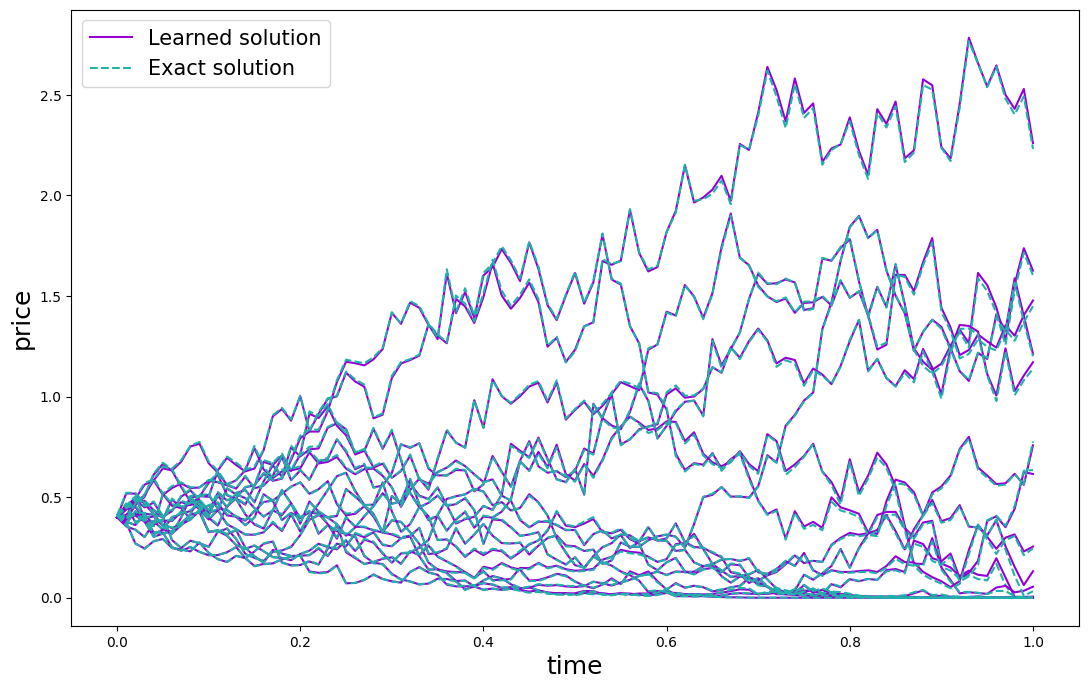

In [25]:
# config = {"s":10, "r":0.03, "sigma": 0.3, "kappa":1.01}
# config = {"s":10, "r":0.03, "sigma": 0.3}
config = {"s":10*[9.5], "r":[0.03], "rho": [0.1], "sigma": 10*[0.3], "kappa": [1.01]}
res = get_option_price_curve_d_10(mytrainer.model.module, 100, 16 ,config)
#  for data in datas: 
plot_mc_curves(res["t"], res["y_pred"], res["y_true"])

In [5]:
scores_test = mytrainer._test_loop()
scores_test["current"]

{'time': 0.19418573379516602,
 'steps': 1,
 'overall time': 7.570988178253174,
 'overall steps': 2.0,
 'mse': 0.00013983888493385166,
 'L2^2': 2.953582225018181e-05,
 'mae': 0.006628999020904303,
 'L1': 0.0034780758433043957,
 'L1_std': 0.00417599780485034,
 'L2': 0.005434686950522708}

In [48]:
config = {
  "bs": 120000,
  "checkpoint": True,
  "factor": 6,
  "gpus": 1,
  "levels": 4,
  "lr": 0.01,
  "lr_decay": 0.25,
  "lr_decay_patience": 2,
  "min_lr": 1e-08,
  "mode": "avg_bs_basket",
  "n_iterations": 30,
  "n_test_batches": 1,
  "n_train_batches": 2000,
  "net": "DeepONet",
  "norm_layer": "layernorm",
  "num_depth": 7,
  "num_width": 75,
  "opt": "adamw",
  "pde": "BSbasket",
  "seed": 0,
  "size_t_x_u": [
    1,
    10,
    13
  ],
  "unfreeze": "all",
  "unfreeze_patience": 1,
  "weight_decay": 0.01
}

mytrainer = trainer.Trainer(config)
path = "/home/ycui/Documents/my_deepkol/exp/avg_bs_basket_2023_10_31_17_27_14/Trainer_2023-10-31_17-27-14/Trainer_ad10d_00005_5_num_depth=7,num_width=75,seed=0_2023-10-31_17-27-14/checkpoint_000016/model.pth"
# mytrainer.net.PI_layers(torch.randn(1,10,1, device=torch.device("cuda"))) # add it when loading checkpoint with the input shape same as the experiment
mytrainer.load_checkpoint(path)

/home/ycui/.conda/envs/torch/lib/python3.10/site-packages/ray/tune/trainable/trainable.py:1080: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
`UnifiedLogger` will be removed in Ray 2.7.
  self._result_logger = UnifiedLogger(config, self._logdir, loggers=None)
/home/ycui/.conda/envs/torch/lib/python3.10/site-packages/ray/tune/logger/unified.py:53: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
The `JsonLogger interface is deprecated in favor of the `ray.tune.json.JsonLoggerCallback` interface and will be removed in Ray 2.7.
  self._loggers.append(cls(self.config, self.logdir, self.trial))
/home/ycui/.conda/envs/torch/lib/python3.10/site-packages/ray/tune/logger/unified.py:53: RayDeprecationWarning: This API

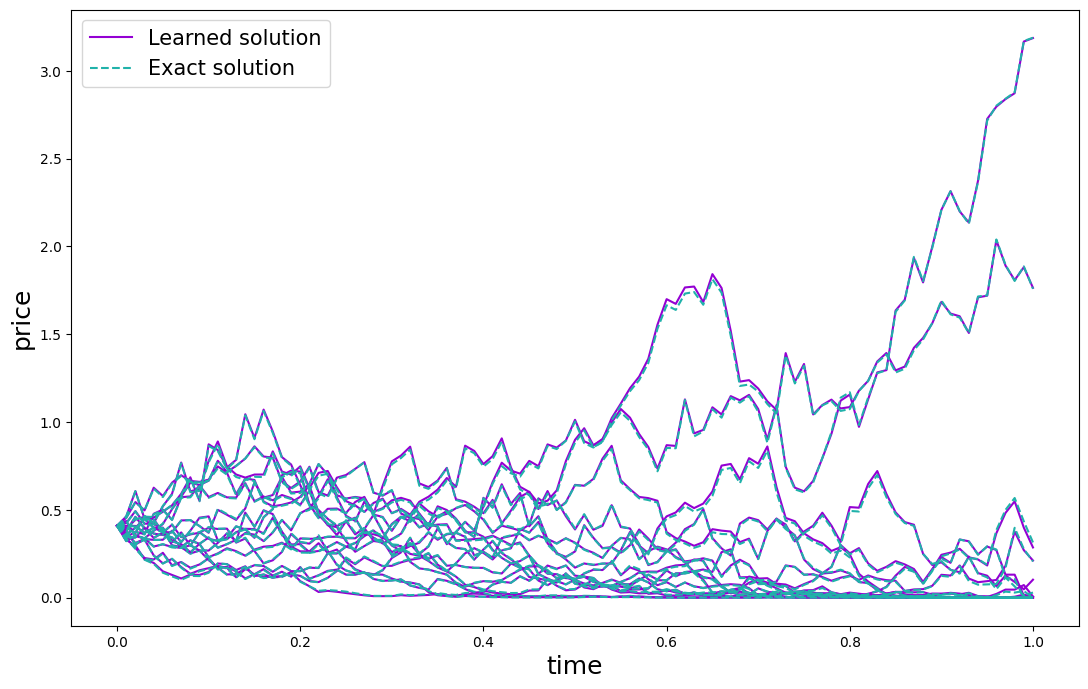

In [63]:
# config = {"s":10, "r":0.03, "sigma": 0.3, "kappa":1.01}
# config = {"s":10, "r":0.03, "sigma": 0.3}
config = {"s":10*[9.5], "r":[0.03], "rho": [0.1], "sigma": 10*[0.3], "kappa": [1.01]}
res = get_option_price_curve_d_10(mytrainer.model.module, 100, 16 ,config)
#  for data in datas: 
plot_mc_curves(res["t"], res["y_pred"], res["y_true"])

In [4]:
config = {
  "bs": 120000,
  "checkpoint": True,
  "factor": 6,
  "gpus": 1,
  "in_channels": 11,
  "kernel_size": 15,
  "levels": 4,
  "lr": 0.01,
  "lr_decay": 0.25,
  "lr_decay_patience": 2,
  "min_lr": 1e-08,
  "mode": "avg_bs_basket_TI_PI",
  "n_iterations": 30,
  "n_test_batches": 1,
  "n_train_batches": 2000,
  "net": "DeepKernelONetwithPI",
  "norm_layer": "layernorm",
  "num_assets": 10,
  "num_depth": 7,
  "num_outputs": 6,
  "num_timepoints": 20,
  "num_width": 75,
  "opt": "adamw",
  "out_channels": 4,
  "pde": "BSbasketTI",
  "pi_layer": [
    100,
    100
  ],
  "seed": 0,
  "size_t_x_u": [
    1,
    10,
    13
  ],
  "unfreeze": "all",
  "unfreeze_patience": 1,
  "weight_decay": 0.01
}

mytrainer = trainer.Trainer(config)
path = "/home/ycui/Documents/my_deepkol/exp/avg_bs_basket_TI_PI_2023_11_24_20_36_02/Trainer_2023-11-24_20-36-02/Trainer_07720_00011_11_num_depth=7,num_width=75,pi_layer=100_100,seed=0_2023-11-24_20-36-02/checkpoint_000019/model.pth"
mytrainer.net.PI_layers(torch.randn(1,10,1, device=torch.device("cuda"))) # add it when loading checkpoint with the input shape same as the experiment
mytrainer.net.kernel(torch.randn(1,11,20, device=torch.device("cuda"))) # add it when loading checkpoint with the input shape same as the experiment
mytrainer.load_checkpoint(path)

/home/ycui/.conda/envs/torch/lib/python3.10/site-packages/ray/tune/trainable/trainable.py:1080: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
`UnifiedLogger` will be removed in Ray 2.7.
  self._result_logger = UnifiedLogger(config, self._logdir, loggers=None)
/home/ycui/.conda/envs/torch/lib/python3.10/site-packages/ray/tune/logger/unified.py:53: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
The `JsonLogger interface is deprecated in favor of the `ray.tune.json.JsonLoggerCallback` interface and will be removed in Ray 2.7.
  self._loggers.append(cls(self.config, self.logdir, self.trial))
/home/ycui/.conda/envs/torch/lib/python3.10/site-packages/ray/tune/logger/unified.py:53: RayDeprecationWarning: This API

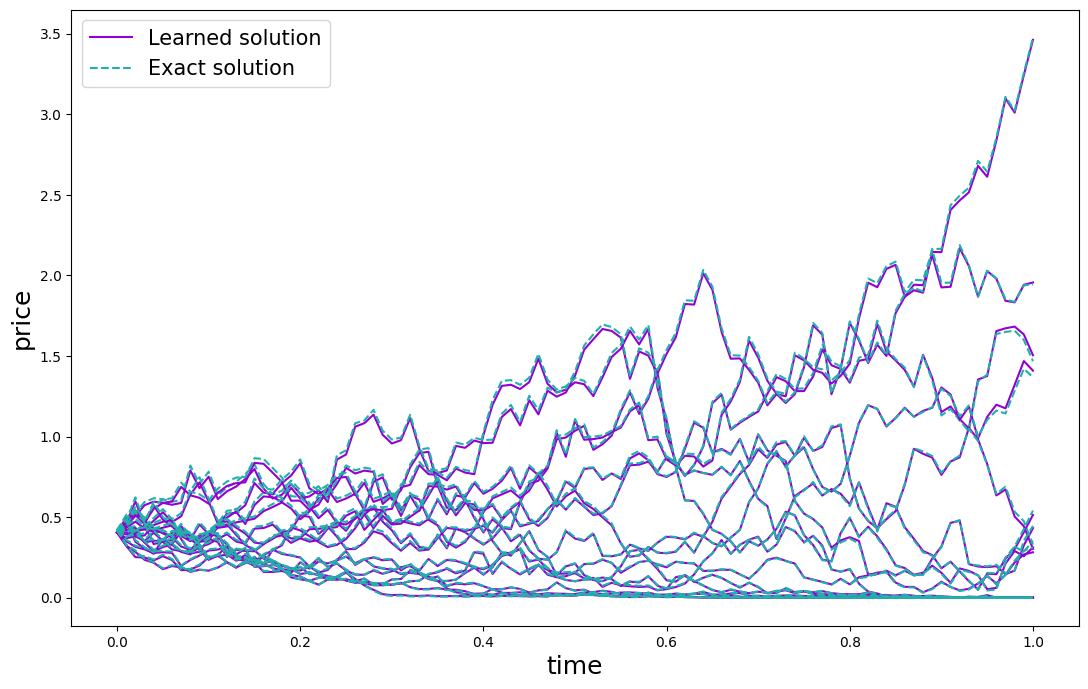

In [62]:
# config = {"s":10, "r":0.03, "sigma": 0.3, "kappa":1.01}
# config = {"s":10, "r":0.03, "sigma": 0.3}
config = {"s":10*[9.5], "r":[0.03], "r0":[0.03], "r1": [0.002], "r2":[0.006],  "rho": [0.1], "sigma_bar": 10*[0.3], "beta":10*[0.03], "kappa": [1.01]}
res = get_option_price_curve_d_10(mytrainer.model.module, 100, 16 ,config)
#  for data in datas: 
plot_mc_curves(res["t"], res["y_pred"], res["y_true"])

In [4]:
config = {
  "bs": 120000,
  "checkpoint": True,
  "factor": 6,
  "gpus": 1,
  "in_channels": 11,
  "kernel_size": 15,
  "levels": 4,
  "lr": 0.01,
  "lr_decay": 0.25,
  "lr_decay_patience": 2,
  "min_lr": 1e-08,
  "mode": "avg_bs_basket_TI",
  "n_iterations": 30,
  "n_test_batches": 1,
  "n_train_batches": 2000,
  "net": "DeepKernelONet",
  "norm_layer": "layernorm",
  "num_depth": 7,
  "num_outputs": 6,
  "num_timepoints": 20,
  "num_width": 75,
  "opt": "adamw",
  "out_channels": 4,
  "pde": "BSbasketTI",
  "seed": 0,
  "size_t_x_u": [
    1,
    10,
    13
  ],
  "unfreeze": "all",
  "unfreeze_patience": 1,
  "weight_decay": 0.01
}

mytrainer = trainer.Trainer(config)
path = "/home/ycui/Documents/my_deepkol/exp/avg_bs_basket_TI_2023_11_24_00_18_58/Trainer_2023-11-24_00-18-58/Trainer_01600_00005_5_num_depth=7,num_width=75,seed=0_2023-11-24_00-18-58/checkpoint_000020/model.pth"
# mytrainer.net.PI_layers(torch.randn(1,10,1, device=torch.device("cuda"))) # add it when loading checkpoint with the input shape same as the experiment
mytrainer.net.kernel(torch.randn(1,11,20, device=torch.device("cuda"))) # add it when loading checkpoint with the input shape same as the experiment
mytrainer.load_checkpoint(path)

/home/ycui/.conda/envs/torch/lib/python3.10/site-packages/ray/tune/trainable/trainable.py:1080: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
`UnifiedLogger` will be removed in Ray 2.7.
  self._result_logger = UnifiedLogger(config, self._logdir, loggers=None)
/home/ycui/.conda/envs/torch/lib/python3.10/site-packages/ray/tune/logger/unified.py:53: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
The `JsonLogger interface is deprecated in favor of the `ray.tune.json.JsonLoggerCallback` interface and will be removed in Ray 2.7.
  self._loggers.append(cls(self.config, self.logdir, self.trial))
/home/ycui/.conda/envs/torch/lib/python3.10/site-packages/ray/tune/logger/unified.py:53: RayDeprecationWarning: This API

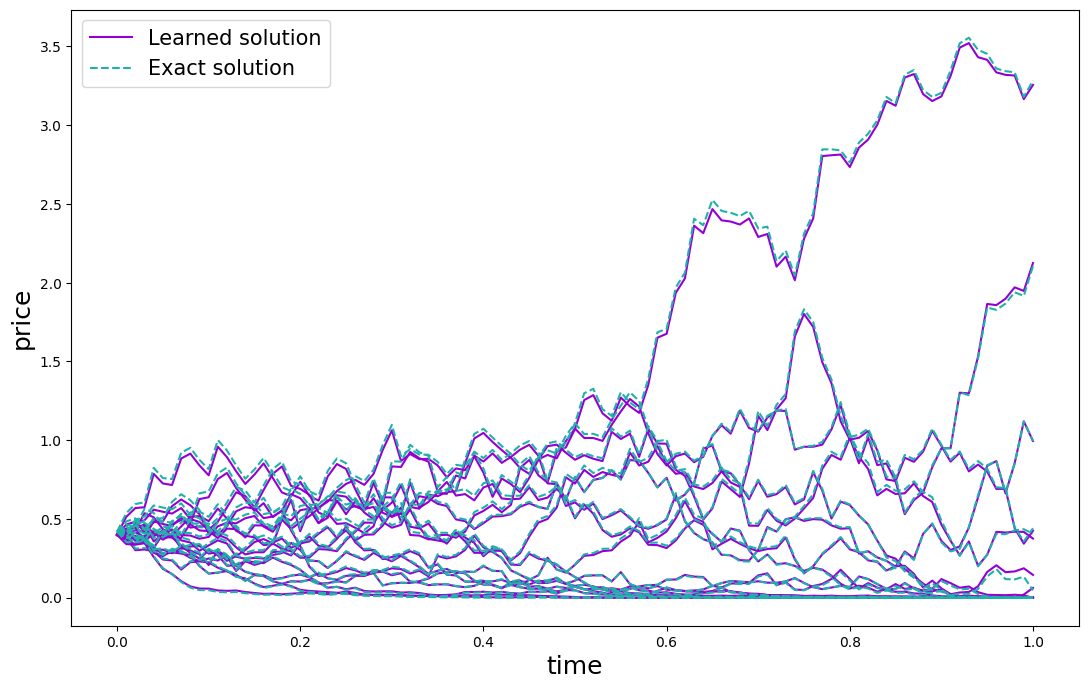

In [47]:
# config = {"s":10, "r":0.03, "sigma": 0.3, "kappa":1.01}
# config = {"s":10, "r":0.03, "sigma": 0.3}
config = {"s":10*[9.5], "r":[0.03], "r0":[0.03], "r1": [0.002], "r2":[0.006],  "rho": [0.1], "sigma_bar": 10*[0.3], "beta":10*[0.03], "kappa": [1.01]}
res = get_option_price_curve_d_10(mytrainer.model.module, 100, 16 ,config)
#  for data in datas: 
plot_mc_curves(res["t"], res["y_pred"], res["y_true"])

In [27]:
config = {
  "bs": 120000,
  "checkpoint": True,
  "factor": 6,
  "gpus": 1,
  "levels": 4,
  "lr": 0.01,
  "lr_decay": 0.25,
  "lr_decay_patience": 2,
  "min_lr": 1e-08,
  "mode": "avg_MJDbasket",
  "n_iterations": 30,
  "n_test_batches": 1,
  "n_train_batches": 2000,
  "net": "DeepONet",
  "norm_layer": "layernorm",
  "num_depth": 7,
  "num_width": 175,
  "opt": "adamw",
  "pde": "MJDbasket",
  "seed": 0,
  "size_t_x_u": [
    1,
    10,
    35
  ],
  "unfreeze": "all",
  "unfreeze_patience": 1,
  "weight_decay": 0.01
}

mytrainer = trainer.Trainer(config)
path = "/home/ycui/Documents/my_deepkol/exp/avg_MJDbasket_2024_01_28_17_00_37/Trainer_2024-01-28_17-00-37/Trainer_b47a7_00022_22_num_depth=7,num_width=175,seed=0_2024-01-28_17-00-38/checkpoint_000026/model.pth"
mytrainer.load_checkpoint(path)

/home/ycui/.conda/envs/torch/lib/python3.10/site-packages/ray/tune/trainable/trainable.py:1080: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
`UnifiedLogger` will be removed in Ray 2.7.
  self._result_logger = UnifiedLogger(config, self._logdir, loggers=None)
/home/ycui/.conda/envs/torch/lib/python3.10/site-packages/ray/tune/logger/unified.py:53: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
The `JsonLogger interface is deprecated in favor of the `ray.tune.json.JsonLoggerCallback` interface and will be removed in Ray 2.7.
  self._loggers.append(cls(self.config, self.logdir, self.trial))
/home/ycui/.conda/envs/torch/lib/python3.10/site-packages/ray/tune/logger/unified.py:53: RayDeprecationWarning: This API

Begin to calculate the solution.Begin to calculate the solution.

Begin to calculate the solution.
The iteration ends with completion of requirements.
The iteration ends with completion of requirements.
The iteration ends with completion of requirements.
Begin to calculate the solution.Begin to calculate the solution.

Begin to calculate the solution.
The iteration ends with completion of requirements.
The iteration ends with completion of requirements.
The iteration ends with completion of requirements.


Begin to calculate the solution.
The iteration exceeds the maximum iteration number.


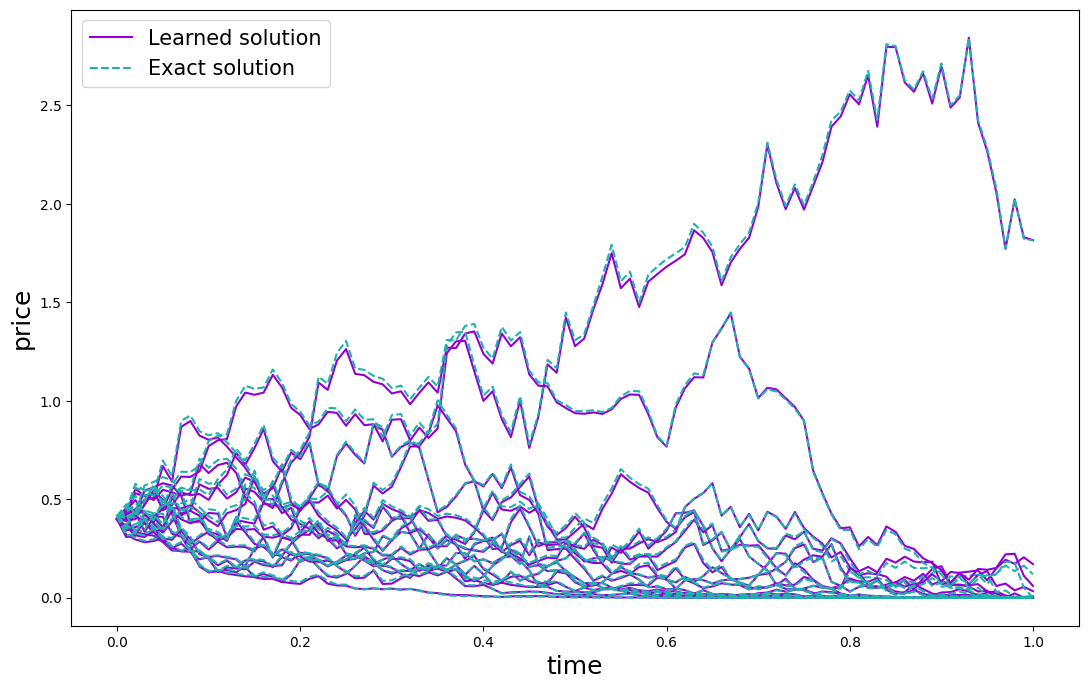

In [99]:
config = {"s":10*[9.5], "r":[0.03], "rho_b": [0.1], "sigma": 10*[0.3], "kappa": [1.01], "lambda": [15], "m": 10*[0], "delta": 10*[0.02], "rho_j": [0.1]}
res = get_option_price_curve_d_10(mytrainer.model.module, 100, 16 ,config)
#  for data in datas: 
plot_mc_curves(res["t"], res["y_pred"], res["y_true"])